## sybil

###Imports + Load

In [1]:
import pandas as pd
import numpy as np
import csv

UDP_FILE  = "udp_packets.csv"
RSSI_FILE = "sniffer_frames.csv"

udp = pd.read_csv(UDP_FILE)

# Robust RSSI load (skips broken rows if any)
rssi = pd.read_csv(
    RSSI_FILE,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

udp.head(), rssi.head()


(   run_id                    scenario_id    ts_gateway   node_id  boot_id  \
 0     202  S1C_SYBIL_ONLY_ECG_WITH_NOISE  1.770732e+09  noise_01    13934   
 1     202  S1C_SYBIL_ONLY_ECG_WITH_NOISE  1.770732e+09  noise_01    13934   
 2     202  S1C_SYBIL_ONLY_ECG_WITH_NOISE  1.770732e+09  noise_01    13934   
 3     202  S1C_SYBIL_ONLY_ECG_WITH_NOISE  1.770732e+09  noise_01    13934   
 4     202  S1C_SYBIL_ONLY_ECG_WITH_NOISE  1.770732e+09  noise_01    13934   
 
    seq msg_type  payload_len       iat  seq_gap  seq_reset_flag  dup_seq_flag  \
 0    0    NOISE           22 -1.000000       -1               0             0   
 1    1    NOISE           22  0.000082        1               0             0   
 2    2    NOISE           22  0.024618        1               0             0   
 3    3    NOISE           22  0.000057        1               0             0   
 4    4    NOISE           22  0.000014        1               0             0   
 
    out_of_order_flag  first_packet_

###Clean + Convert types

In [2]:
# --- UDP cleaning ---
udp["ts_gateway"] = pd.to_numeric(udp["ts_gateway"], errors="coerce")
udp = udp.dropna(subset=["ts_gateway", "node_id"])

# Ensure numeric columns are numeric
num_cols_udp = [
    "boot_id","seq","payload_len","iat","seq_gap",
    "seq_reset_flag","dup_seq_flag","out_of_order_flag",
    "first_packet_flag","boot_change_flag"
]
for c in num_cols_udp:
    if c in udp.columns:
        udp[c] = pd.to_numeric(udp[c], errors="coerce")

# --- RSSI cleaning ---
rssi["ts_sniffer"] = pd.to_numeric(rssi["ts_sniffer"], errors="coerce")
rssi["rssi_dbm"]   = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
rssi["src_mac"]    = rssi["src_mac"].astype(str).str.lower()

rssi = rssi.dropna(subset=["ts_sniffer","src_mac","rssi_dbm"])

udp.shape, rssi.shape


((644175, 15), (372582, 3))

###Align time to common start

In [3]:
start_time = max(udp["ts_gateway"].min(), rssi["ts_sniffer"].min())

udp["t"]  = udp["ts_gateway"]  - start_time
rssi["t"] = rssi["ts_sniffer"] - start_time

end_time = min(udp["t"].max(), rssi["t"].max())

start_time, end_time


(np.float64(1770732025.969741), np.float64(7112.472009897232))

###Provide node_id → MAC mapping (Phase A / stable mapping)


In [5]:
# TODO: replace with your real mapping
node_to_mac = {
    "noise_01": "34:94:54:aa:79:e0"
}
node_to_mac = {k: v.lower() for k,v in node_to_mac.items()}


In [4]:
rssi["src_mac"].value_counts().head(15)



src_mac
98:a9:42:17:7e:dc    74981
98:a9:42:7d:5a:16    58709
d8:d8:66:4e:79:d4    50738
98:a9:42:09:aa:f1    47621
d8:d8:66:4d:b9:1c    46713
50:2e:91:2c:3d:62    44368
34:94:54:aa:79:e0    13939
d8:d8:66:43:22:3c     6957
f4:52:93:da:8c:c0     5818
d8:d8:66:35:f2:66     5723
c0:35:32:0c:af:6f     4174
e4:0d:36:db:86:de     3794
00:42:38:bf:87:8b     2293
50:5a:65:ea:de:93     1820
04:68:74:5e:7a:d3      871
Name: count, dtype: int64

###Window feature extraction (full)

In [6]:
WINDOW = 5.0   # seconds
STRIDE = 1.0   # seconds
MIN_RSSI_FRAMES = 5  # below this, treat RSSI as missing

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else np.nan

def safe_std(x):
    return float(np.nanstd(x)) if len(x) else np.nan

def extract_window_features(udp, rssi, node_to_mac, window=5.0, stride=1.0):
    rows = []
    win_starts = np.arange(0, end_time - window + 1e-9, stride)

    # sort once for speed/stability
    udp = udp.sort_values("t")
    rssi = rssi.sort_values("t")

    for node_id, mac in node_to_mac.items():
        mac = mac.lower()

        udp_node = udp[udp["node_id"] == node_id]
        rssi_node = rssi[rssi["src_mac"] == mac]

        for ws in win_starts:
            we = ws + window

            u = udp_node[(udp_node["t"] >= ws) & (udp_node["t"] < we)]
            s = rssi_node[(rssi_node["t"] >= ws) & (rssi_node["t"] < we)]

            # --- UDP features ---
            pps = len(u) / window
            iat_vals = u["iat"].to_numpy() if "iat" in u.columns else np.array([])
            iat_vals = iat_vals[iat_vals >= 0]  # ignore -1 placeholders

            seq_gap_vals = u["seq_gap"].to_numpy() if "seq_gap" in u.columns else np.array([])
            seq_gap_vals = seq_gap_vals[seq_gap_vals >= 0]

            def rate(col):
                if col not in u.columns or len(u) == 0:
                    return np.nan
                return float(np.nanmean(u[col].to_numpy()))

            # --- RSSI features ---
            rssi_vals = s["rssi_dbm"].to_numpy()
            rssi_count = len(rssi_vals)

            rssi_missing = 1 if rssi_count < MIN_RSSI_FRAMES else 0

            rows.append({
                "node_id": node_id,
                "node_mac": mac,
                "window_start_s": float(ws),
                "window_end_s": float(we),

                # UDP
                "pps": float(pps),
                "iat_mean": safe_mean(iat_vals),
                "iat_std": safe_std(iat_vals),
                "seq_gap_mean": safe_mean(seq_gap_vals),
                "seq_gap_max": float(np.nanmax(seq_gap_vals)) if len(seq_gap_vals) else np.nan,
                "seq_reset_rate": rate("seq_reset_flag"),
                "dup_seq_rate": rate("dup_seq_flag"),
                "out_of_order_rate": rate("out_of_order_flag"),
                "boot_change_rate": rate("boot_change_flag"),
                "udp_pkt_count": int(len(u)),

                # RSSI
                "rssi_mean": safe_mean(rssi_vals),
                "rssi_std": safe_std(rssi_vals),
                "rssi_min": float(np.nanmin(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_max": float(np.nanmax(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_frame_count": int(rssi_count),
                "rssi_missing": int(rssi_missing),
            })

    return pd.DataFrame(rows)

features = extract_window_features(udp, rssi, node_to_mac, window=WINDOW, stride=STRIDE)
features.head(), features.shape


(    node_id           node_mac  window_start_s  window_end_s    pps  iat_mean  \
 0  noise_01  34:94:54:aa:79:e0             0.0           5.0   91.4  0.010953   
 1  noise_01  34:94:54:aa:79:e0             1.0           6.0   93.2  0.010761   
 2  noise_01  34:94:54:aa:79:e0             2.0           7.0  106.6  0.009634   
 3  noise_01  34:94:54:aa:79:e0             3.0           8.0   98.6  0.009938   
 4  noise_01  34:94:54:aa:79:e0             4.0           9.0   99.8  0.010025   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.021532      1.096491         13.0             0.0           0.0   
 1  0.019091      1.094421         13.0             0.0           0.0   
 2  0.014130      1.082552         13.0             0.0           0.0   
 3  0.011718      1.000000          1.0             0.0           0.0   
 4  0.011499      1.000000          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean 

Fill missing RSSI values

In [7]:
# Fill missing RSSI values when RSSI is missing
features["rssi_mean"] = features["rssi_mean"].fillna(-100)
features["rssi_std"]  = features["rssi_std"].fillna(0)
features["rssi_min"]  = features["rssi_min"].fillna(-100)
features["rssi_max"]  = features["rssi_max"].fillna(-100)

# Fill missing UDP stats too (rare)
features["iat_mean"] = features["iat_mean"].fillna(-1)
features["iat_std"]  = features["iat_std"].fillna(-1)
features["seq_gap_mean"] = features["seq_gap_mean"].fillna(-1)
features["seq_gap_max"]  = features["seq_gap_max"].fillna(-1)

features.isna().sum().sort_values(ascending=False).head(10)


node_id           0
node_mac          0
window_start_s    0
window_end_s      0
pps               0
iat_mean          0
iat_std           0
seq_gap_mean      0
seq_gap_max       0
seq_reset_rate    0
dtype: int64

Save and download

In [8]:
OUT_FILE = "phaseA_window_features.csv"
features.to_csv(OUT_FILE, index=False)

### rssi + udp


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "phaseA_window_features.csv"   # change if your file name differs
df = pd.read_csv(FILE)

df.head(), df.shape


(    node_id           node_mac  window_start_s  window_end_s    pps  iat_mean  \
 0  noise_01  34:94:54:aa:79:e0             0.0           5.0   91.4  0.010953   
 1  noise_01  34:94:54:aa:79:e0             1.0           6.0   93.2  0.010761   
 2  noise_01  34:94:54:aa:79:e0             2.0           7.0  106.6  0.009634   
 3  noise_01  34:94:54:aa:79:e0             3.0           8.0   98.6  0.009938   
 4  noise_01  34:94:54:aa:79:e0             4.0           9.0   99.8  0.010025   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.021532      1.096491         13.0             0.0           0.0   
 1  0.019091      1.094421         13.0             0.0           0.0   
 2  0.014130      1.082552         13.0             0.0           0.0   
 3  0.011718      1.000000          1.0             0.0           0.0   
 4  0.011499      1.000000          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean 

Select only feature columns (numeric)

In [10]:
# Columns you usually do NOT want as features
exclude = {"node_id","node_mac","window_start_s","window_end_s"}

num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

num_cols


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

Histogram for each feature (one-by-one)

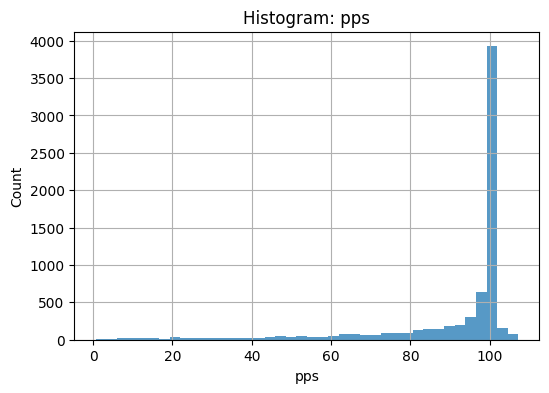

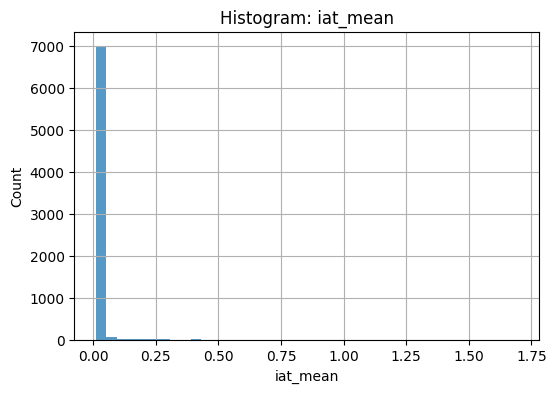

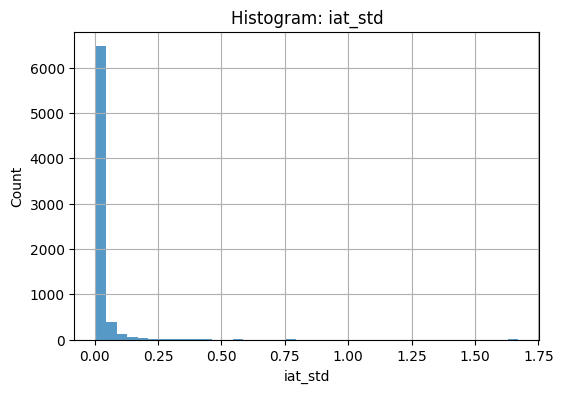

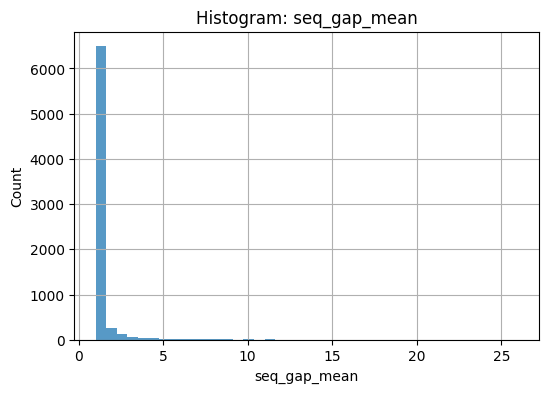

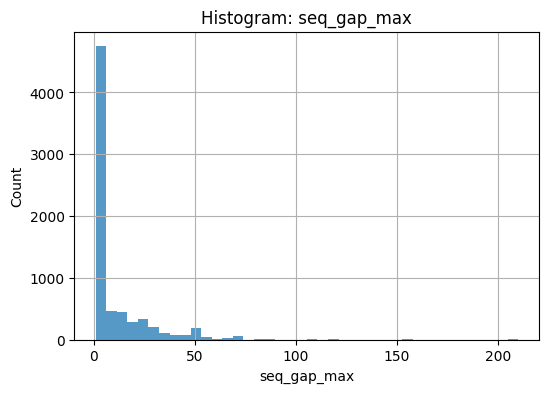

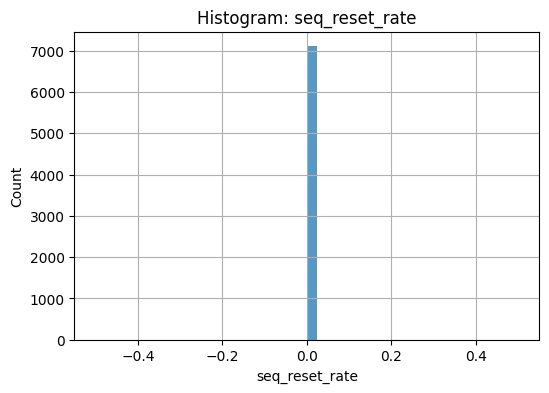

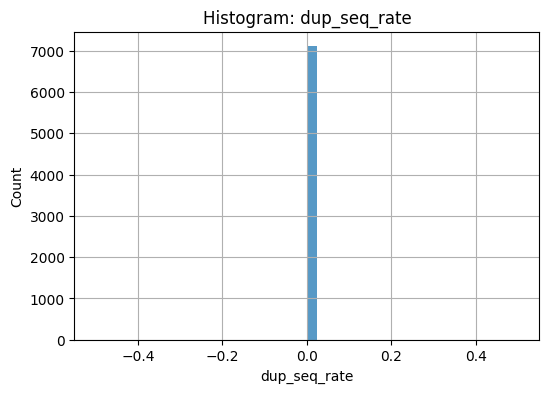

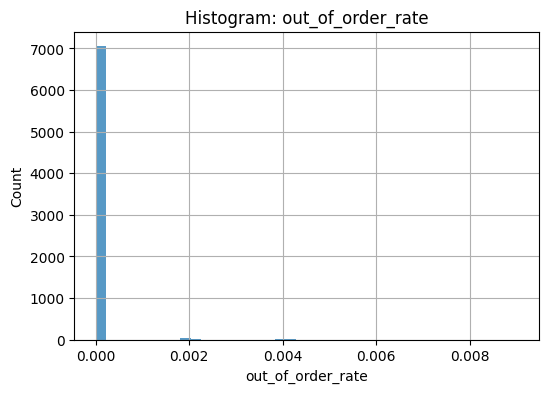

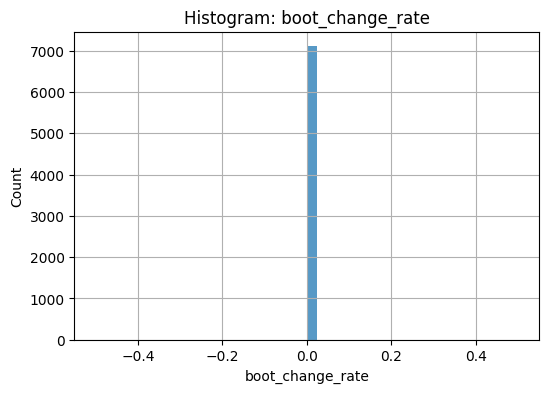

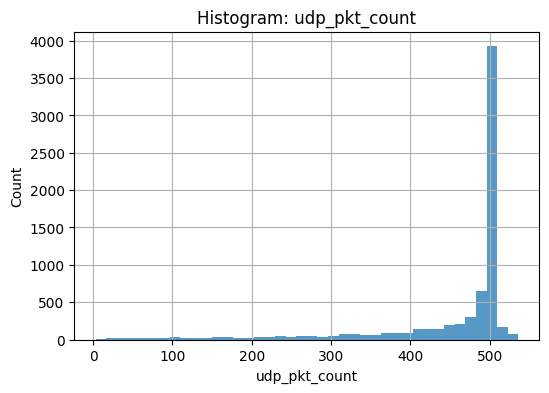

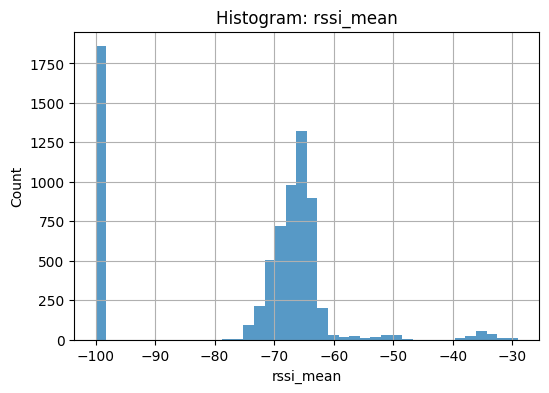

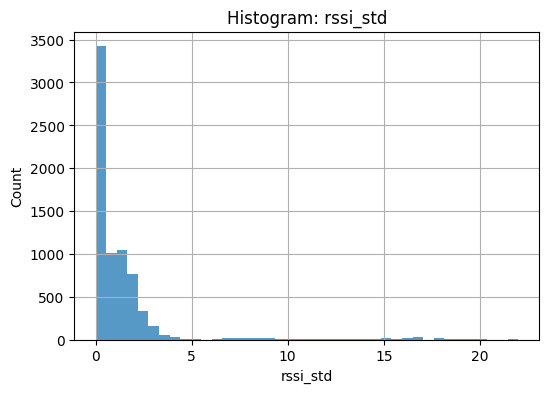

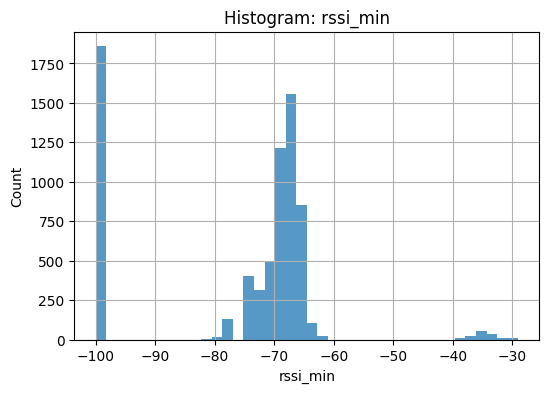

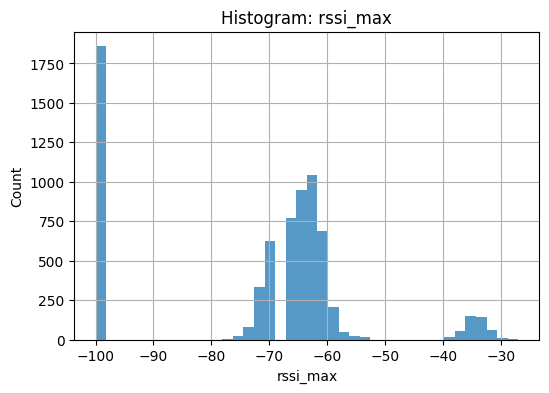

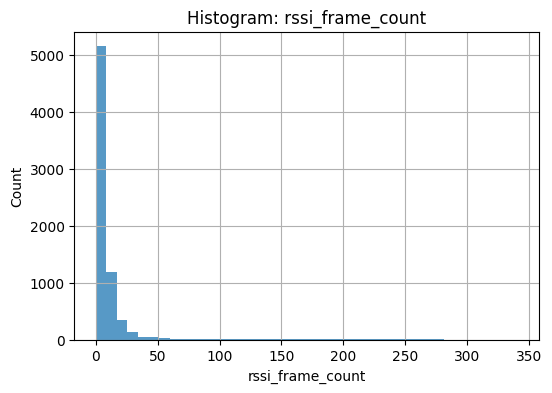

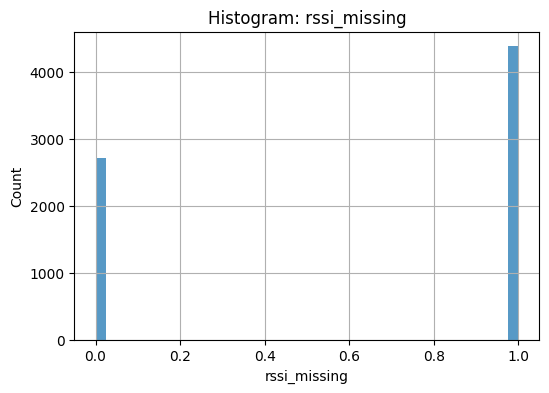

In [11]:
for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40, alpha=0.75)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


Histogram per node_id

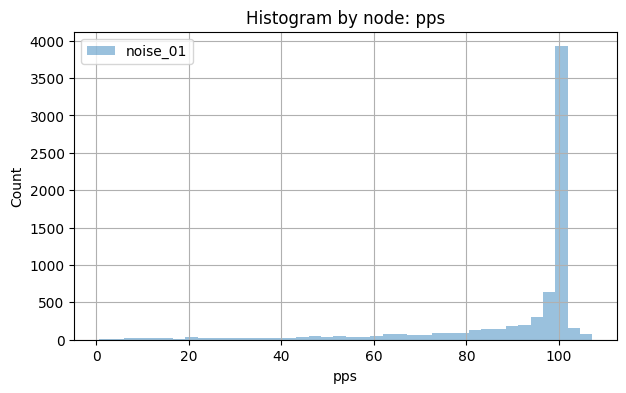

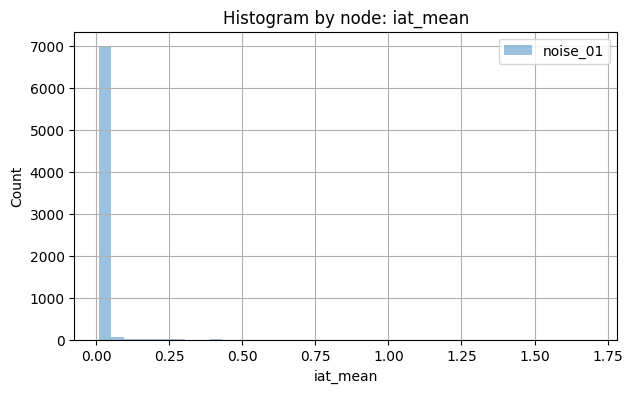

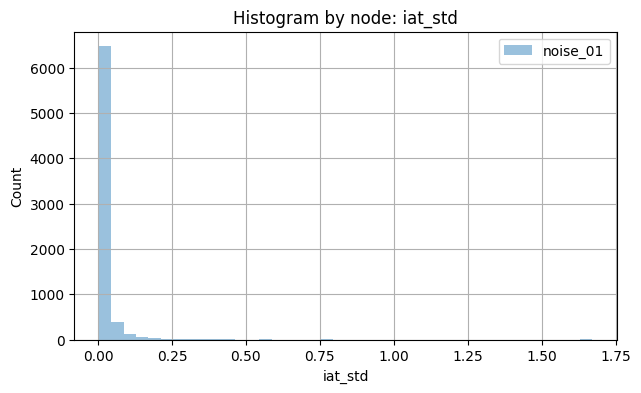

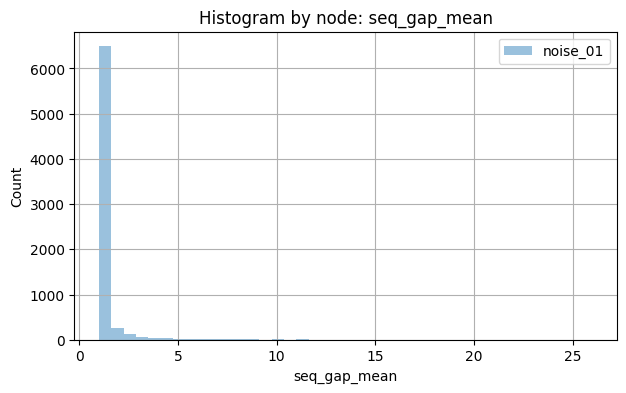

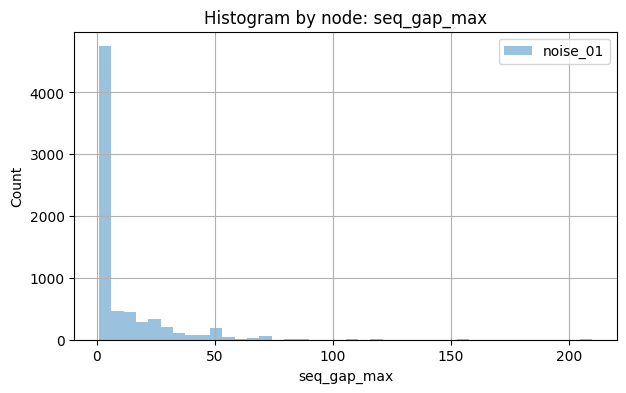

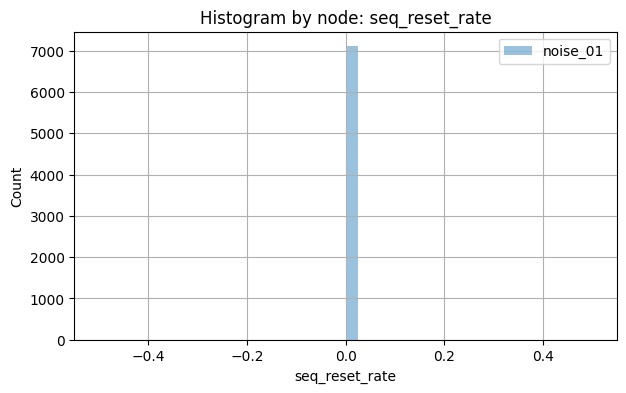

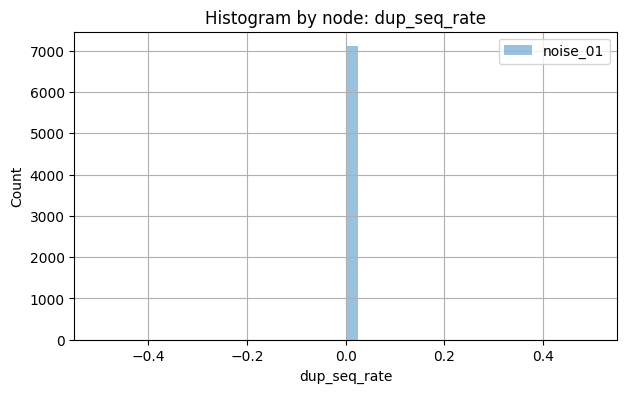

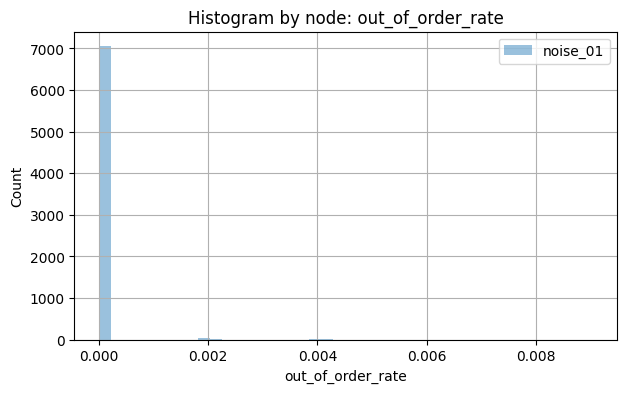

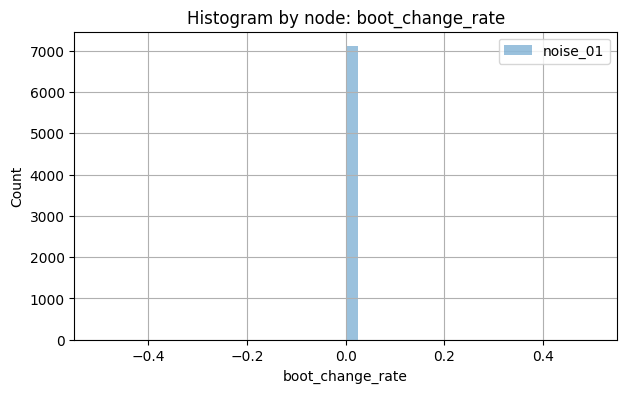

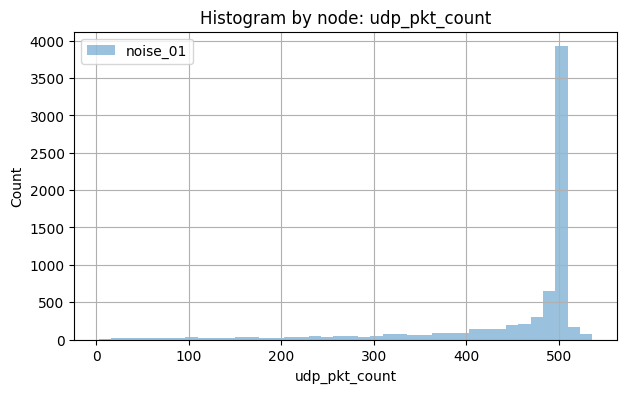

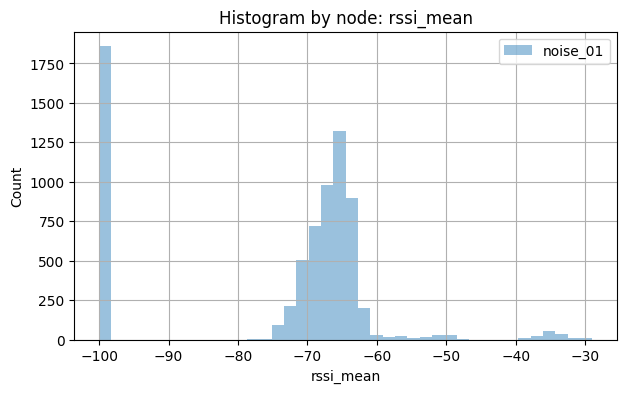

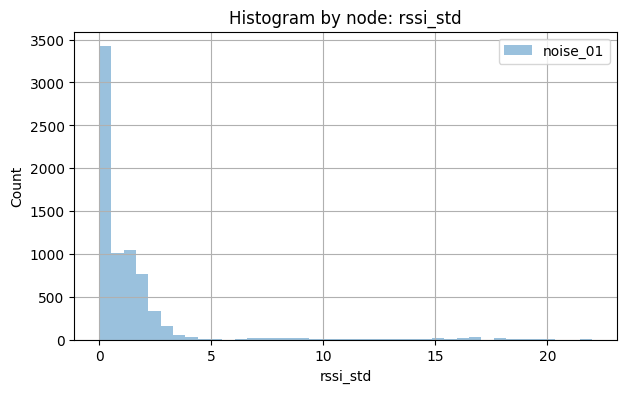

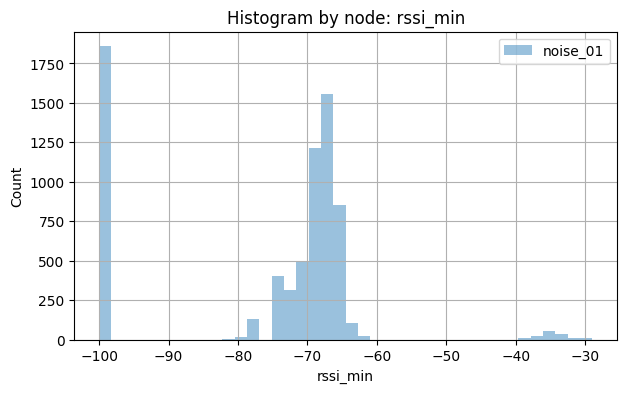

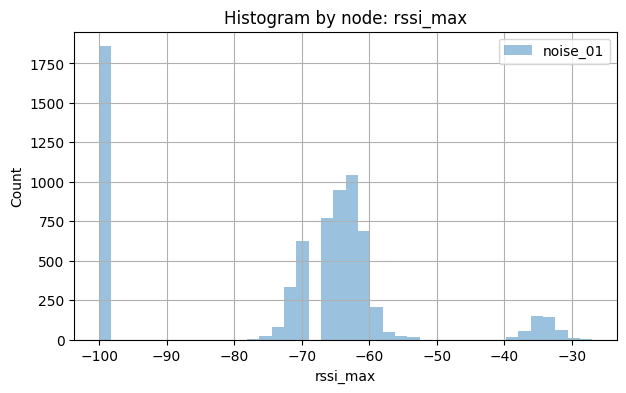

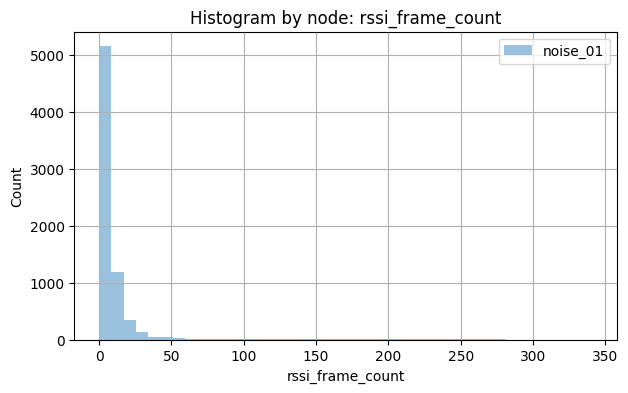

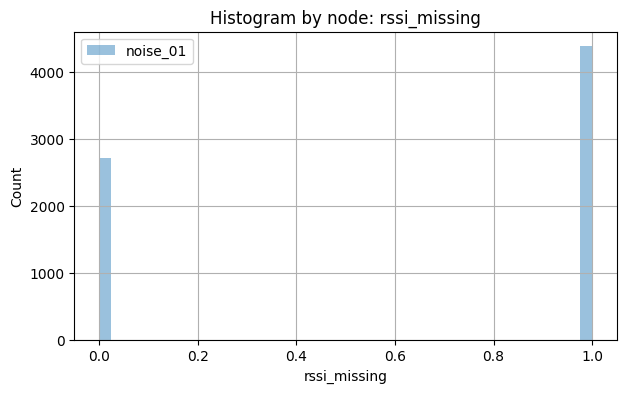

In [12]:
nodes = df["node_id"].unique().tolist()

for col in num_cols:
    plt.figure(figsize=(7,4))
    for n in nodes:
        x = df[df["node_id"] == n][col].dropna()
        if len(x) == 0:
            continue
        plt.hist(x, bins=40, alpha=0.45, label=n)

    plt.title(f"Histogram by node: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()


quality checks

In [13]:
# Missing values per column
df[num_cols].isna().mean().sort_values(ascending=False).head(15)


pps                  0.0
iat_mean             0.0
iat_std              0.0
seq_gap_mean         0.0
seq_gap_max          0.0
seq_reset_rate       0.0
dup_seq_rate         0.0
out_of_order_rate    0.0
boot_change_rate     0.0
udp_pkt_count        0.0
rssi_mean            0.0
rssi_std             0.0
rssi_min             0.0
rssi_max             0.0
rssi_frame_count     0.0
dtype: float64

In [14]:
# Basic stats
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
pps,7108.0,90.568514,19.484265,0.600000,90.800000,99.800000,100.000000,107.200000
iat_mean,7108.0,0.014167,0.037173,0.009357,0.009999,0.010008,0.010964,1.697656
iat_std,7108.0,0.024264,0.055786,0.003565,0.007998,0.013396,0.022886,1.670727
seq_gap_mean,7108.0,1.280923,1.198752,1.000000,1.000000,1.000000,1.083770,26.000000
seq_gap_max,7108.0,9.787845,16.811564,1.000000,1.000000,1.000000,13.000000,210.000000
seq_reset_rate,7108.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
dup_seq_rate,7108.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
out_of_order_rate,7108.0,0.000021,0.000276,0.000000,0.000000,0.000000,0.000000,0.009036
boot_change_rate,7108.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
udp_pkt_count,7108.0,452.842572,97.421324,3.000000,454.000000,499.000000,500.000000,536.000000


In [15]:
# RSSI missing rate (important if you use RSSI)
if "rssi_missing" in df.columns:
    print(df["rssi_missing"].value_counts(normalize=True))


rssi_missing
1    0.617192
0    0.382808
Name: proportion, dtype: float64


###label sybil

In [16]:
df["label"] = 1

In [17]:
df["label"].value_counts()


label
1    7108
Name: count, dtype: int64

In [18]:
df.to_csv("window_features_sybil_sybil_labeled.csv", index=False)



##Normal



In [27]:
import pandas as pd
import numpy as np
import csv

UDP_FILE  = "udp_packets1.csv"
RSSI_FILE = "sniffer_frames1.csv"

udp = pd.read_csv(UDP_FILE)

# Robust RSSI load (skips broken rows if any)
rssi = pd.read_csv(
    RSSI_FILE,
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

udp.head(), rssi.head()


(   run_id           scenario_id    ts_gateway node_id  boot_id  seq msg_type  \
 0       2  S0_NORMAL_LOW_SIGNAL  1.770986e+09  eeg_01    51205    0      EEG   
 1       2  S0_NORMAL_LOW_SIGNAL  1.770986e+09  eeg_01    51205    1      EEG   
 2       2  S0_NORMAL_LOW_SIGNAL  1.770986e+09  eeg_01    51205    2      EEG   
 3       2  S0_NORMAL_LOW_SIGNAL  1.770986e+09  eeg_01    51205    3      EEG   
 4       2  S0_NORMAL_LOW_SIGNAL  1.770986e+09  eeg_01    51205    4      EEG   
 
    payload_len       iat  seq_gap  seq_reset_flag  dup_seq_flag  \
 0           18 -1.000000       -1               0             0   
 1           18  0.028314        1               0             0   
 2           18  0.046256        1               0             0   
 3           18  0.031124        1               0             0   
 4           18  0.058631        1               0             0   
 
    out_of_order_flag  first_packet_flag  boot_change_flag  
 0                  0                  1 

In [28]:
rssi.head()

,ts_sniffer,src_mac,rssi_dbm
0,1770986310,98:a9:42:17:7e:dc,-29.0
1,1770986310,d8:d8:66:35:f2:66,-33.0
2,1770986310,98:a9:42:17:7e:dc,-27.0
3,1770986310,98:a9:42:17:7e:dc,-27.0
4,1770986310,98:a9:42:17:7e:dc,-27.0


In [29]:
# --- UDP cleaning ---
udp["ts_gateway"] = pd.to_numeric(udp["ts_gateway"], errors="coerce")
udp = udp.dropna(subset=["ts_gateway", "node_id"])

# Ensure numeric columns are numeric
num_cols_udp = [
    "boot_id","seq","payload_len","iat","seq_gap",
    "seq_reset_flag","dup_seq_flag","out_of_order_flag",
    "first_packet_flag","boot_change_flag"
]
for c in num_cols_udp:
    if c in udp.columns:
        udp[c] = pd.to_numeric(udp[c], errors="coerce")

# --- RSSI cleaning ---
rssi["ts_sniffer"] = pd.to_numeric(rssi["ts_sniffer"], errors="coerce")
rssi["rssi_dbm"]   = pd.to_numeric(rssi["rssi_dbm"], errors="coerce")
rssi["src_mac"]    = rssi["src_mac"].astype(str).str.lower()

rssi = rssi.dropna(subset=["ts_sniffer","src_mac","rssi_dbm"])

udp.shape, rssi.shape


((457717, 15), (709030, 3))

In [30]:
start_time = max(udp["ts_gateway"].min(), rssi["ts_sniffer"].min())

udp["t"]  = udp["ts_gateway"]  - start_time
rssi["t"] = rssi["ts_sniffer"] - start_time

end_time = min(udp["t"].max(), rssi["t"].max())

start_time, end_time


(np.float64(1770986345.569303), np.float64(17339.430696964264))

In [31]:
rssi["src_mac"].value_counts().head(15)


src_mac
98:a9:42:17:7e:dc    311599
48:e7:da:aa:5e:95    122670
08:d1:f9:e8:84:c0     89144
84:1f:e8:36:62:98     51550
d8:d8:66:4e:79:d4     30779
98:a9:42:97:ae:03     16723
74:22:bb:03:88:97     11108
d8:d8:66:35:f2:66      9873
d8:d8:66:4f:d3:ea      9594
d8:d8:66:4d:b9:1c      9543
1c:b7:96:a3:78:a1      9338
d8:d8:66:35:81:c7      4795
36:3a:b3:2d:de:f9      3919
70:b5:e8:c6:b6:c1      3756
18:d9:8f:2d:46:64      3481
Name: count, dtype: int64

In [32]:
udp["node_id"].value_counts().head(15)

node_id
eeg_01    304626
ecg_01    153091
Name: count, dtype: int64

In [33]:
# TODO: replace with your real mapping
node_to_mac = {
    "ecg_01": "84:1f:e8:36:62:98",
    "eeg_01": "08:d1:f9:e8:84:c0 ",
}
node_to_mac = {k: v.lower() for k,v in node_to_mac.items()}


In [34]:
WINDOW = 5.0   # seconds
STRIDE = 1.0   # seconds
MIN_RSSI_FRAMES = 5  # below this, treat RSSI as missing

def safe_mean(x):
    return float(np.nanmean(x)) if len(x) else np.nan

def safe_std(x):
    return float(np.nanstd(x)) if len(x) else np.nan

def extract_window_features(udp, rssi, node_to_mac, window=5.0, stride=1.0):
    rows = []
    win_starts = np.arange(0, end_time - window + 1e-9, stride)

    # sort once for speed/stability
    udp = udp.sort_values("t")
    rssi = rssi.sort_values("t")

    for node_id, mac in node_to_mac.items():
        mac = mac.lower()

        udp_node = udp[udp["node_id"] == node_id]
        rssi_node = rssi[rssi["src_mac"] == mac]

        for ws in win_starts:
            we = ws + window

            u = udp_node[(udp_node["t"] >= ws) & (udp_node["t"] < we)]
            s = rssi_node[(rssi_node["t"] >= ws) & (rssi_node["t"] < we)]

            # --- UDP features ---
            pps = len(u) / window
            iat_vals = u["iat"].to_numpy() if "iat" in u.columns else np.array([])
            iat_vals = iat_vals[iat_vals >= 0]  # ignore -1 placeholders

            seq_gap_vals = u["seq_gap"].to_numpy() if "seq_gap" in u.columns else np.array([])
            seq_gap_vals = seq_gap_vals[seq_gap_vals >= 0]

            def rate(col):
                if col not in u.columns or len(u) == 0:
                    return np.nan
                return float(np.nanmean(u[col].to_numpy()))

            # --- RSSI features ---
            rssi_vals = s["rssi_dbm"].to_numpy()
            rssi_count = len(rssi_vals)

            rssi_missing = 1 if rssi_count < MIN_RSSI_FRAMES else 0

            rows.append({
                "node_id": node_id,
                "node_mac": mac,
                "window_start_s": float(ws),
                "window_end_s": float(we),

                # UDP
                "pps": float(pps),
                "iat_mean": safe_mean(iat_vals),
                "iat_std": safe_std(iat_vals),
                "seq_gap_mean": safe_mean(seq_gap_vals),
                "seq_gap_max": float(np.nanmax(seq_gap_vals)) if len(seq_gap_vals) else np.nan,
                "seq_reset_rate": rate("seq_reset_flag"),
                "dup_seq_rate": rate("dup_seq_flag"),
                "out_of_order_rate": rate("out_of_order_flag"),
                "boot_change_rate": rate("boot_change_flag"),
                "udp_pkt_count": int(len(u)),

                # RSSI
                "rssi_mean": safe_mean(rssi_vals),
                "rssi_std": safe_std(rssi_vals),
                "rssi_min": float(np.nanmin(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_max": float(np.nanmax(rssi_vals)) if len(rssi_vals) else np.nan,
                "rssi_frame_count": int(rssi_count),
                "rssi_missing": int(rssi_missing),
            })

    return pd.DataFrame(rows)

features = extract_window_features(udp, rssi, node_to_mac, window=WINDOW, stride=STRIDE)
features.head(), features.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0   4.0  0.097858   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0   6.2  0.098747   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0   8.2  0.098850   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099288   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0   9.6  0.103872   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.048302           1.0          1.0             0.0           0.0   
 1  0.040644           1.0          1.0             0.0           0.0   
 2  0.037408           1.0          1.0             0.0           0.0   
 3  0.034212           1.0          1.0             0.0           0.0   
 4  0.039603           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean   rssi_std  \
 0  

In [35]:
# Fill missing RSSI values when RSSI is missing
features["rssi_mean"] = features["rssi_mean"].fillna(-100)
features["rssi_std"]  = features["rssi_std"].fillna(0)
features["rssi_min"]  = features["rssi_min"].fillna(-100)
features["rssi_max"]  = features["rssi_max"].fillna(-100)

# Fill missing UDP stats too (rare)
features["iat_mean"] = features["iat_mean"].fillna(-1)
features["iat_std"]  = features["iat_std"].fillna(-1)
features["seq_gap_mean"] = features["seq_gap_mean"].fillna(-1)
features["seq_gap_max"]  = features["seq_gap_max"].fillna(-1)

features.isna().sum().sort_values(ascending=False).head(10)


boot_change_rate     4616
seq_reset_rate       4616
out_of_order_rate    4616
dup_seq_rate         4616
window_end_s            0
window_start_s          0
node_mac                0
node_id                 0
seq_gap_mean            0
iat_std                 0
dtype: int64

In [36]:
OUT_FILE = "phaseA_window_features1.csv"
features.to_csv(OUT_FILE, index=False)

In [37]:
features["rssi_missing"].value_counts(normalize=True)


rssi_missing
1    0.853764
0    0.146236
Name: proportion, dtype: float64

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "phaseA_window_features1.csv"   # change if your file name differs
df = pd.read_csv(FILE)

df.head(), df.shape


(  node_id           node_mac  window_start_s  window_end_s   pps  iat_mean  \
 0  ecg_01  84:1f:e8:36:62:98             0.0           5.0   4.0  0.097858   
 1  ecg_01  84:1f:e8:36:62:98             1.0           6.0   6.2  0.098747   
 2  ecg_01  84:1f:e8:36:62:98             2.0           7.0   8.2  0.098850   
 3  ecg_01  84:1f:e8:36:62:98             3.0           8.0  10.0  0.099288   
 4  ecg_01  84:1f:e8:36:62:98             4.0           9.0   9.6  0.103872   
 
     iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  dup_seq_rate  \
 0  0.048302           1.0          1.0             0.0           0.0   
 1  0.040644           1.0          1.0             0.0           0.0   
 2  0.037408           1.0          1.0             0.0           0.0   
 3  0.034212           1.0          1.0             0.0           0.0   
 4  0.039603           1.0          1.0             0.0           0.0   
 
    out_of_order_rate  boot_change_rate  udp_pkt_count  rssi_mean   rssi_std  \
 0  

In [39]:
# Columns you usually do NOT want as features
exclude = {"node_id","node_mac","window_start_s","window_end_s"}

num_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

num_cols


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

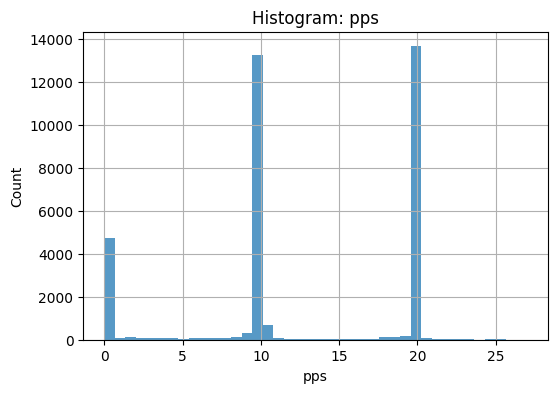

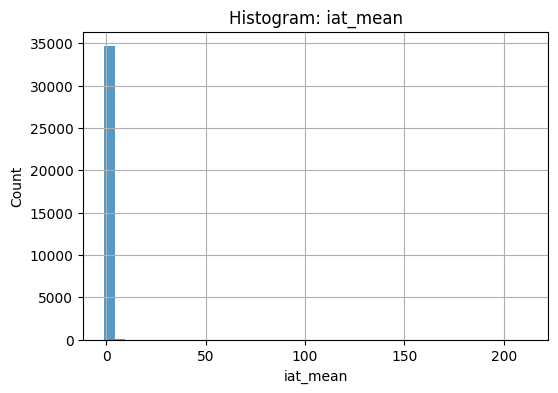

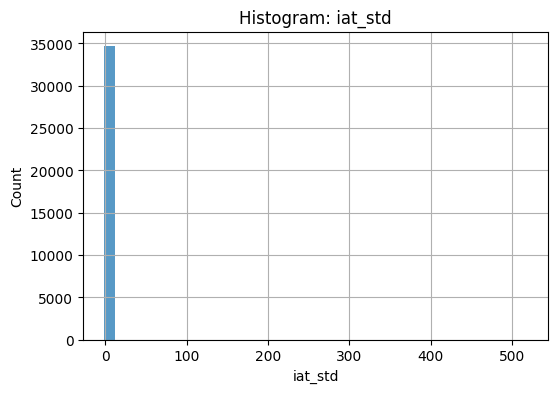

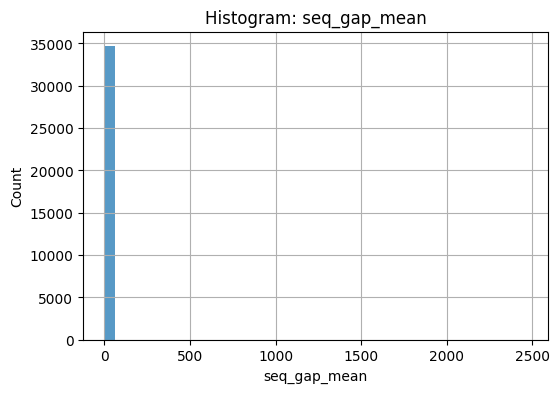

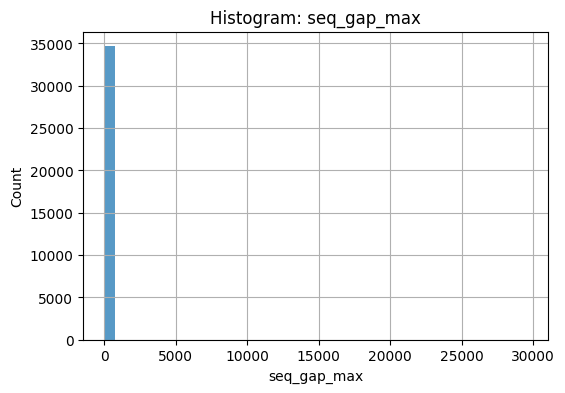

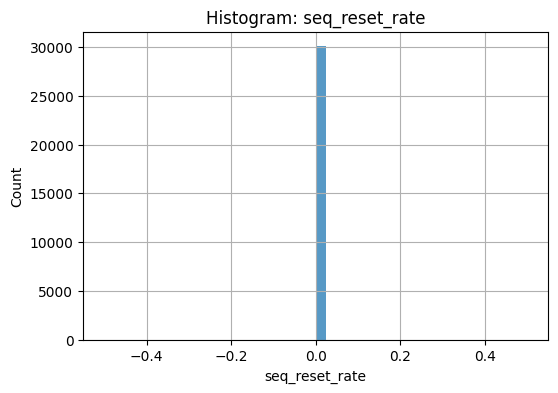

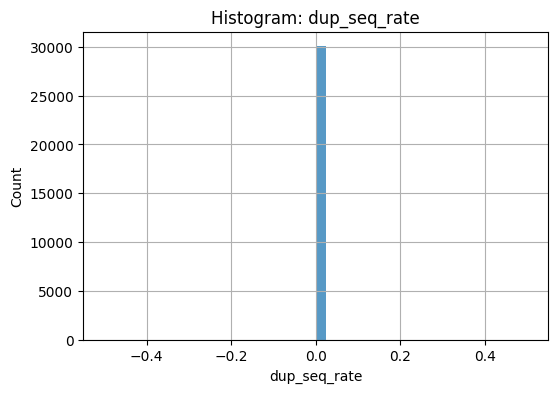

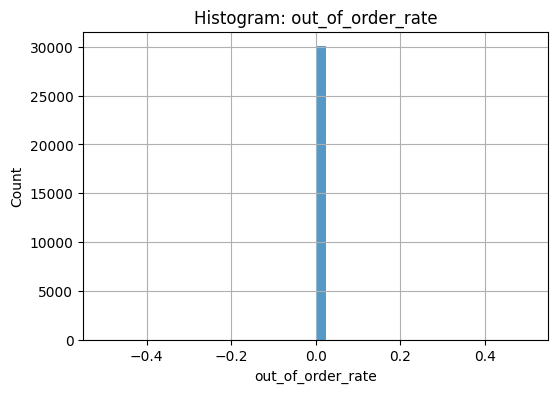

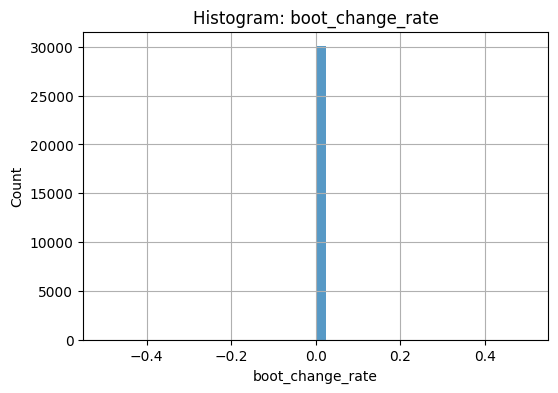

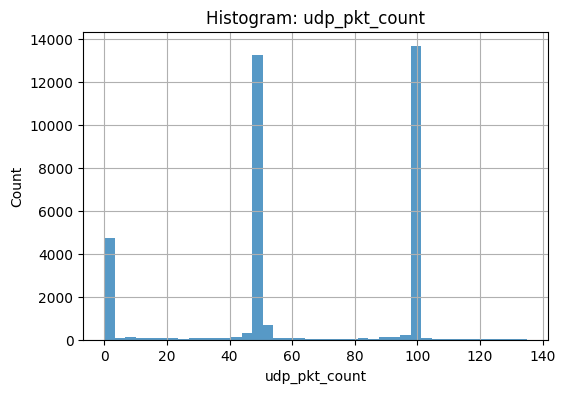

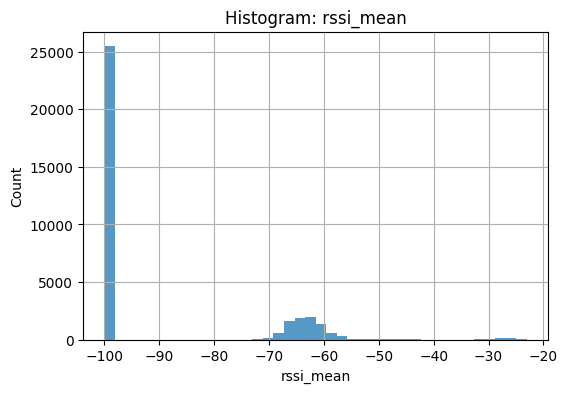

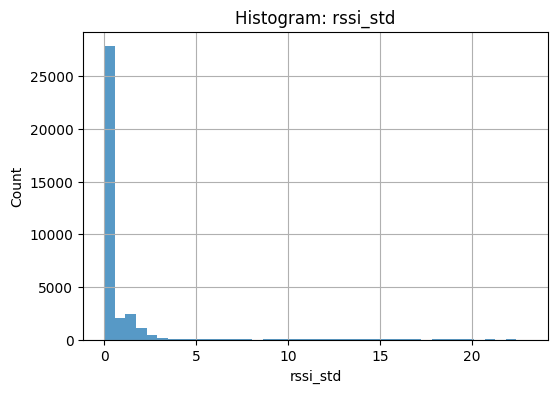

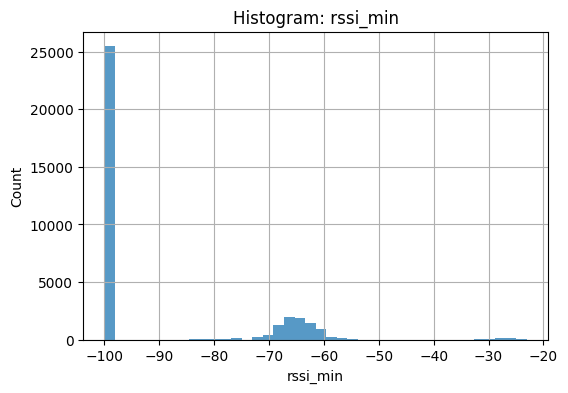

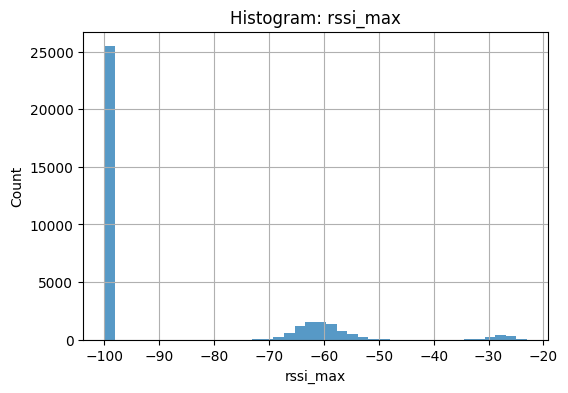

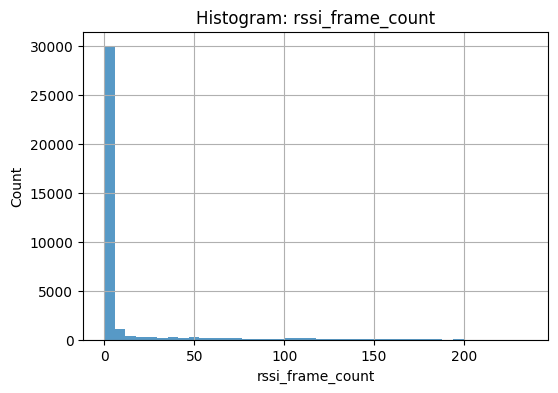

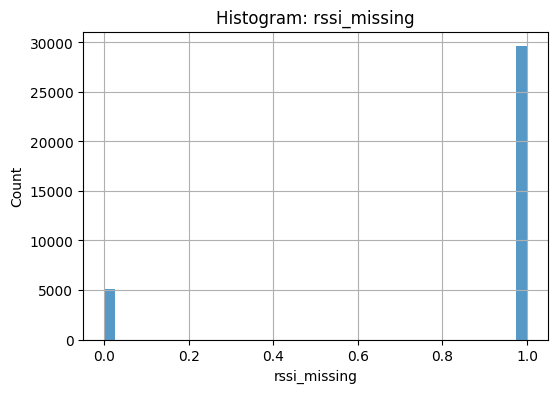

In [40]:
for col in num_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40, alpha=0.75)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


### normal label

In [41]:
df["label"] = 0

In [42]:
df["label"].value_counts()


label
0    34670
Name: count, dtype: int64

In [43]:
df.to_csv("window_features_normal_labeled.csv", index=False)

In [44]:
normal = pd.read_csv("window_features_normal_labeled.csv")
sybil  = pd.read_csv("window_features_sybil_sybil_labeled.csv")

full = pd.concat([normal, sybil], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)


In [ ]:
files.download("dataset_all_labeled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## sybil+ normal


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FILE = "dataset_all_labeled.csv"   # change to your file name
df = pd.read_csv(FILE)

df["label"].value_counts()


label
0    34670
1     7108
Name: count, dtype: int64

Select numeric feature columns

In [46]:
exclude = {
    "node_id","node_mac",
    "window_start_s","window_end_s",
    "label"
}

features = [
    c for c in df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
]

features


['pps',
 'iat_mean',
 'iat_std',
 'seq_gap_mean',
 'seq_gap_max',
 'seq_reset_rate',
 'dup_seq_rate',
 'out_of_order_rate',
 'boot_change_rate',
 'udp_pkt_count',
 'rssi_mean',
 'rssi_std',
 'rssi_min',
 'rssi_max',
 'rssi_frame_count',
 'rssi_missing']

Plot Normal vs Sybil histograms (main analysis)

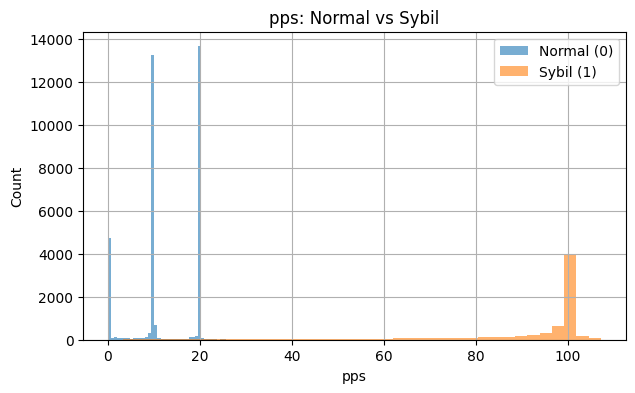

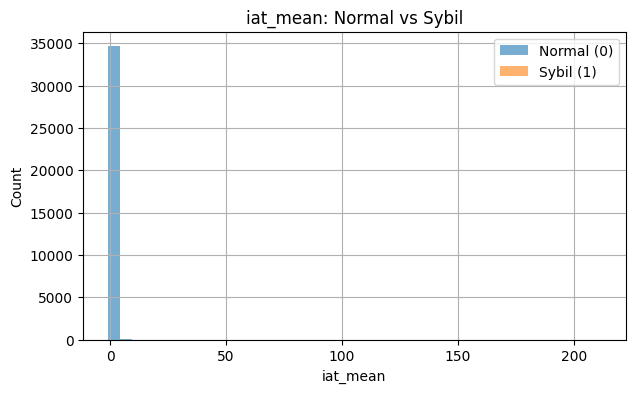

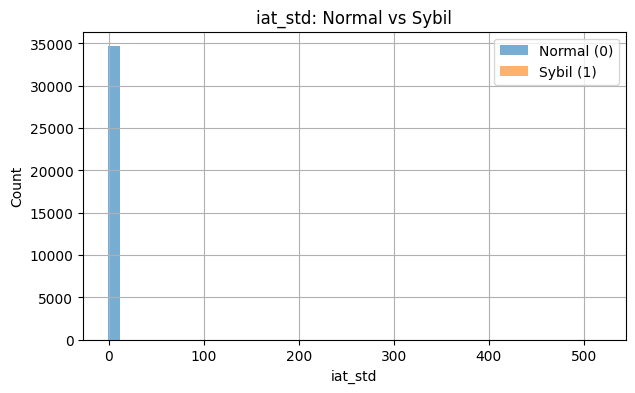

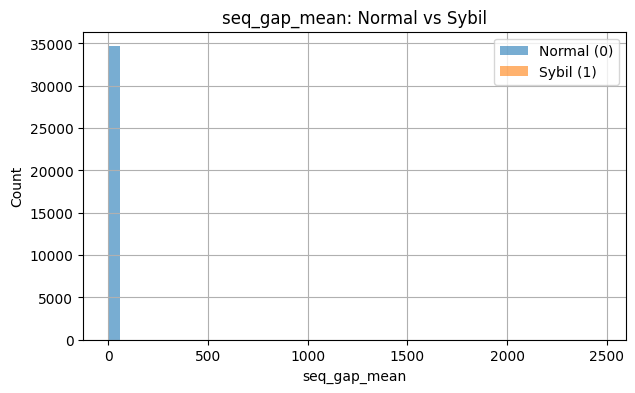

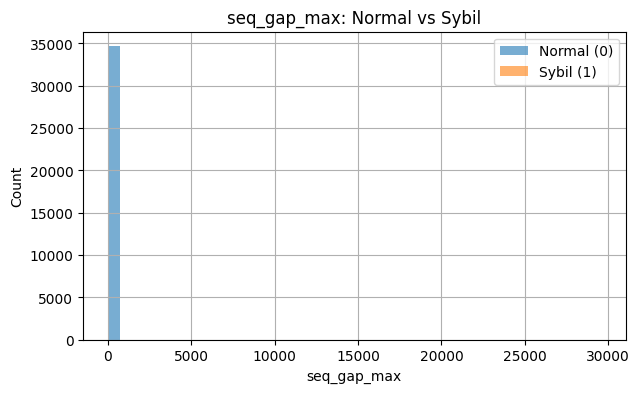

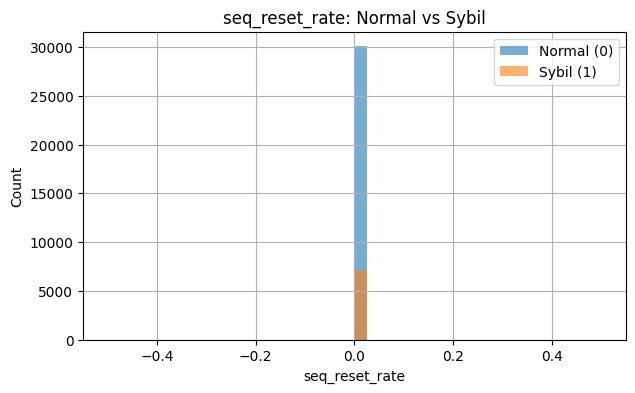

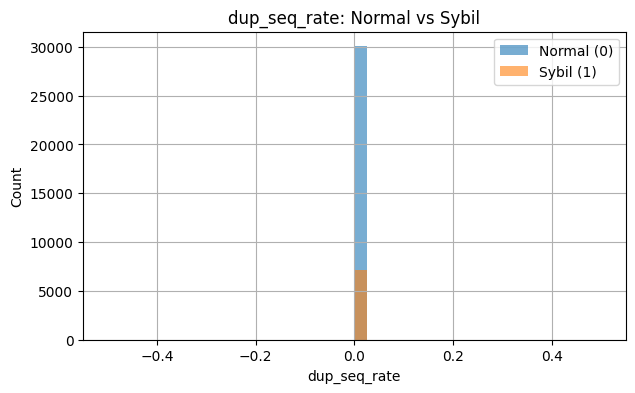

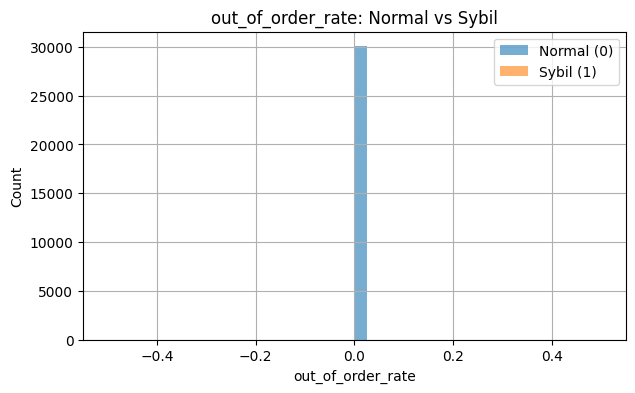

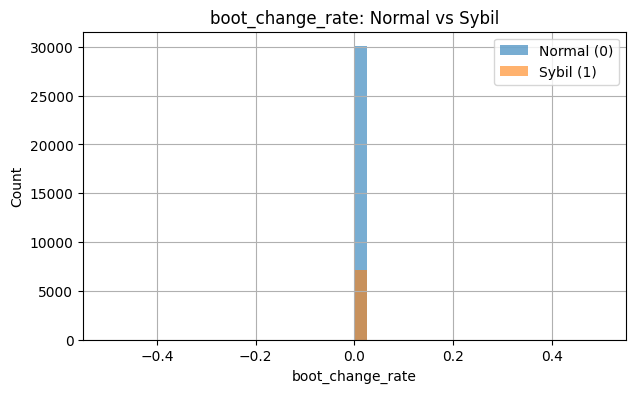

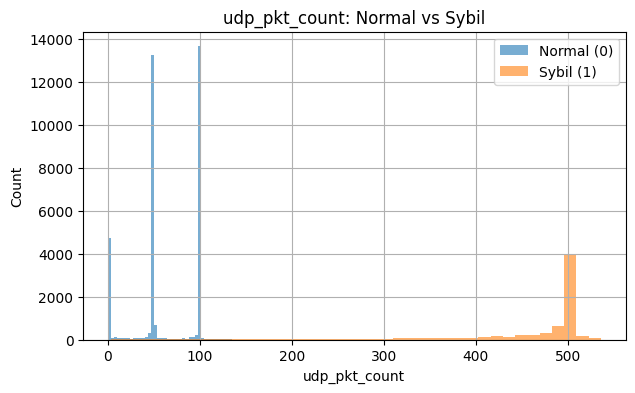

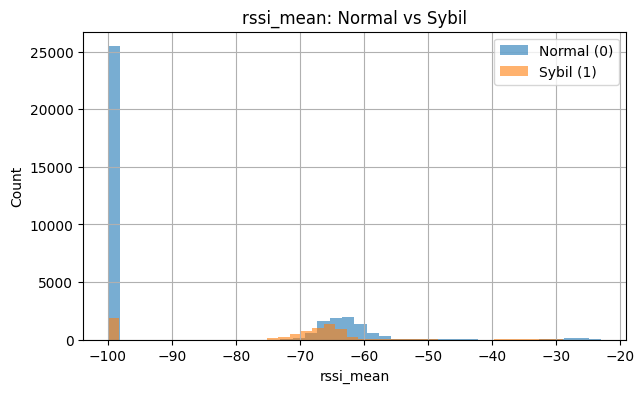

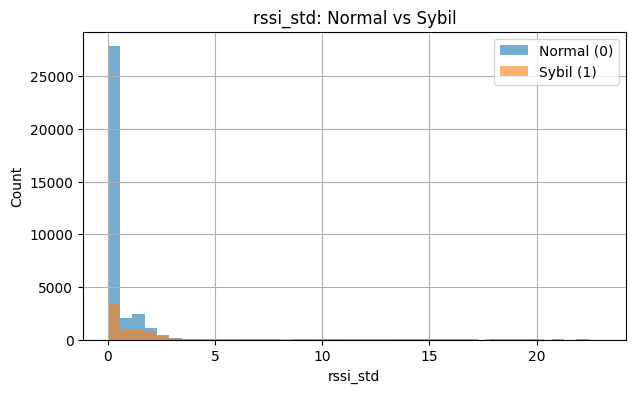

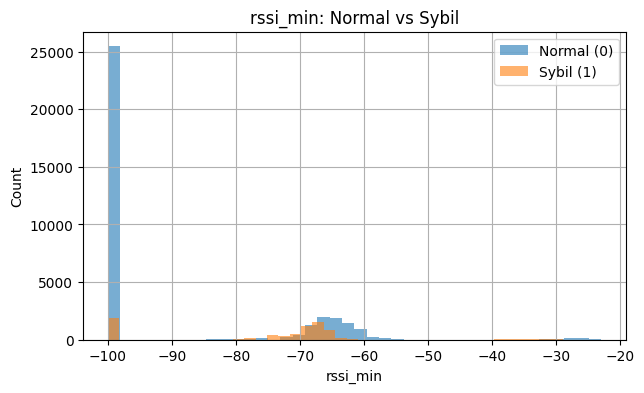

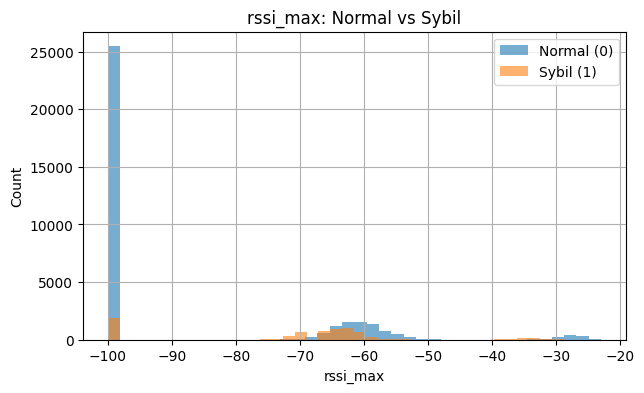

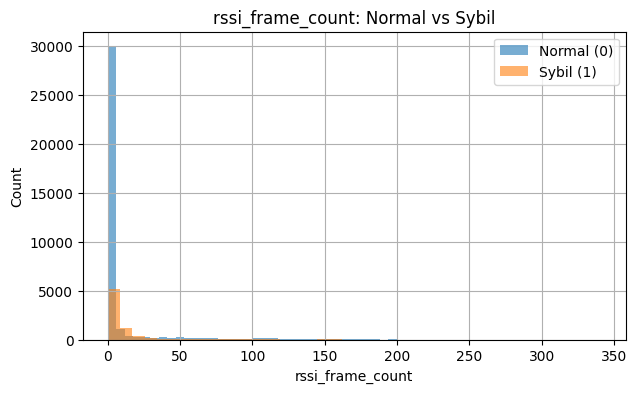

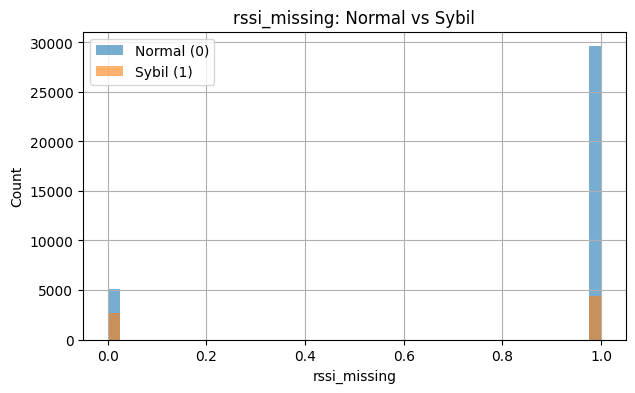

In [47]:
for col in features:

    normal = df[df["label"] == 0][col].dropna()
    sybil  = df[df["label"] == 1][col].dropna()

    plt.figure(figsize=(7,4))

    plt.hist(normal, bins=40, alpha=0.6, label="Normal (0)")
    plt.hist(sybil,  bins=40, alpha=0.6, label="Sybil (1)")

    plt.title(f"{col}: Normal vs Sybil")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)

    plt.show()


How to interpret the graphs

In [48]:
from scipy.stats import wasserstein_distance

scores = []

for col in features:

    n = df[df["label"]==0][col].dropna()
    s = df[df["label"]==1][col].dropna()

    if len(n)>10 and len(s)>10:
        d = wasserstein_distance(n, s)
        scores.append((col, d))

sep = pd.DataFrame(scores, columns=["feature","distance"])
sep.sort_values("distance", ascending=False)


,feature,distance
9,udp_pkt_count,389.485664
0,pps,77.897133
4,seq_gap_max,18.252137
13,rssi_max,16.825474
10,rssi_mean,15.599530
12,rssi_min,14.738079
14,rssi_frame_count,5.304264
3,seq_gap_mean,0.856886
11,rssi_std,0.789412
2,iat_std,0.275803
